In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from process_data import load_data, plot, write_predictions


/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)
print(parent_dir)


/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML


In [4]:
# Load the data
interpolated_dir = os.path.join(parent_dir, "dataset_interpolated_fixed")

# Define features (excluding label)
other_features = [
            "home_has_possession", # Binary indicator
            "end.down",            # Down number (1-4, discrete)
            "home_timeouts_left",  # Discrete count (0-3)
            "away_timeouts_left",  # Discrete count (0-3)
            "score_difference",
        ]
numeric_features = [
    "game_completed",
    "relative_strength", 
    "end.yardsToEndzone", 
    "end.distance",
    "predicted_drive_points_ev"
]
features = ["game_completed", "relative_strength", "score_difference", "home_has_possession", "end.down", "end.distance", "end.yardsToEndzone", "home_timeouts_left", "away_timeouts_left", "predicted_drive_points_ev"] 
label_feature = "home_win"

# Training, validation, and test years
training_years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
validation_years = []
test_years = [2024, 2025]

# Load training data (history_length=0 means no history, just current row)
history_length = 0
training_data = load_data(interpolated_dir, training_years, history_length, features, label_feature, replace_nan_val=0, train=True)

# Load validation data
validation_data = load_data(interpolated_dir, validation_years, history_length, features, label_feature, replace_nan_val=0, train=False)

# Load test data
test_data = load_data(interpolated_dir, test_years, history_length, features, label_feature, replace_nan_val=0, train=False)


Loading data for 2022
  Processing 271 CSV files in parallel with 8 workers...
  Completed processing 2022
Loading data for 2025
skipping  2025
Loading data for 2024
skipping  2024
Loading data for 2023
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2023
Loading data for .DS_Store
Loading data for 2017
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2017
Loading data for 2019
  Processing 256 CSV files in parallel with 8 workers...
  Completed processing 2019
Loading data for 2021
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2021
Loading data for 2020
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2020
Loading data for 2018
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2018
Loading data for 2016
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2016
Loading data for 2022
skipping  2022
Loadin

In [5]:
print(f"Number of training timesteps: {len(training_data)}")
print(f"Number of validation timesteps: {len(validation_data)}")
print(f"Number of test timesteps: {len(test_data)}")


Number of training timesteps: 201
Number of validation timesteps: 0
Number of test timesteps: 201


In [9]:
modules_to_reload = [
    'models.Model',
    'models.svm',
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]

from models.direct_prediction_network_lstm import setup_direct_lstm_models


In [10]:
# Import SVM model setup function
from models.svm import setup_svm_models

# Setup SVM models with validation data
# setup_svm_models expects training_data and test_data in format: {timestep: [{"rows": array, "label": float}]}
# which is exactly what load_data returns
models = setup_svm_models(
    training_data=training_data,
    test_data=validation_data,  # Use validation data for evaluation during training
    numeric_features=numeric_features,
    other_features=other_features,
    all_features=features,
    use_calibration=False,
    optimize_hyperparams=False,
    n_trials=50
)


Processing timestep: 0.0
Timestep 0.0 : Training Loss = 0.6147, Accuracy = 0.6610, Test Loss = 0.6303, Test Accuracy = 0.6413
Processing timestep: 0.005
Timestep 0.005 : Training Loss = 0.6156, Accuracy = 0.6552, Test Loss = 0.6516, Test Accuracy = 0.6316
Processing timestep: 0.01
Timestep 0.01 : Training Loss = 0.6106, Accuracy = 0.6518, Test Loss = 0.6383, Test Accuracy = 0.6273
Processing timestep: 0.015
Timestep 0.015 : Training Loss = 0.6198, Accuracy = 0.6515, Test Loss = 0.6245, Test Accuracy = 0.6656
Processing timestep: 0.02
Timestep 0.02 : Training Loss = 0.6197, Accuracy = 0.6600, Test Loss = 0.6550, Test Accuracy = 0.6098
Processing timestep: 0.025
Timestep 0.025 : Training Loss = 0.6150, Accuracy = 0.6634, Test Loss = 0.6226, Test Accuracy = 0.6898
Processing timestep: 0.03
Timestep 0.03 : Training Loss = 0.6042, Accuracy = 0.6819, Test Loss = 0.6357, Test Accuracy = 0.6305
Processing timestep: 0.035
Timestep 0.035 : Training Loss = 0.6220, Accuracy = 0.6536, Test Loss = 0

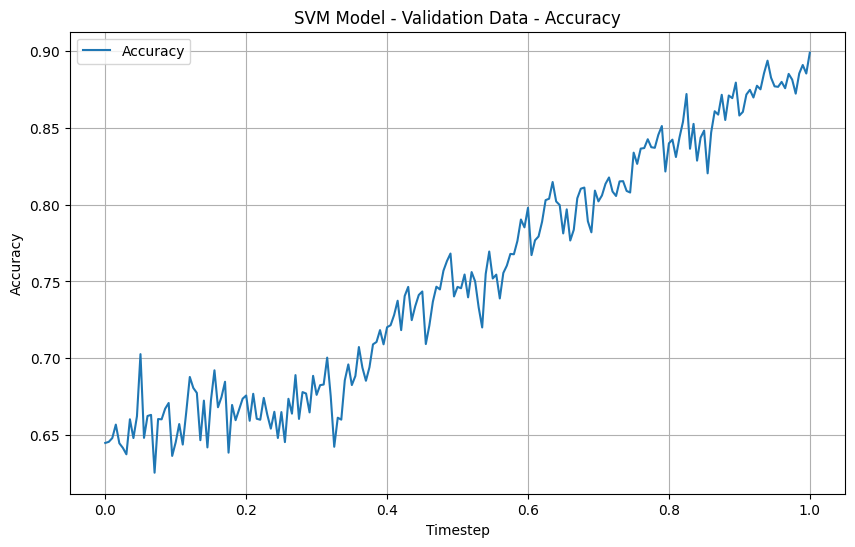

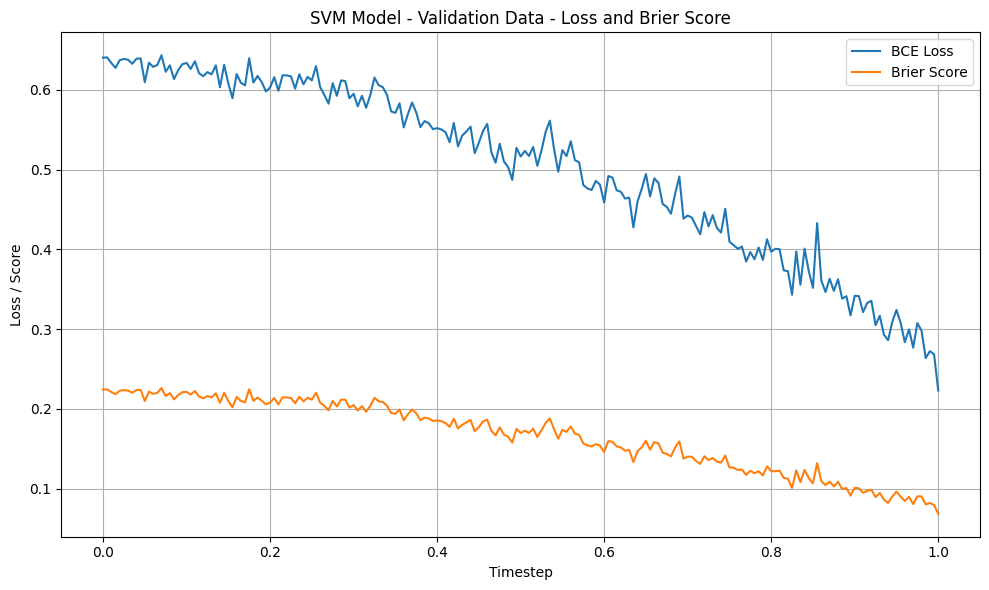

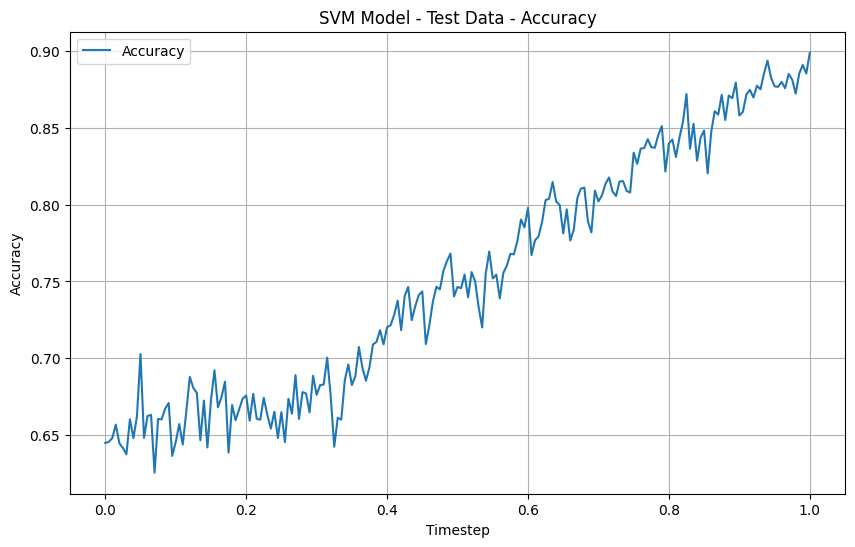

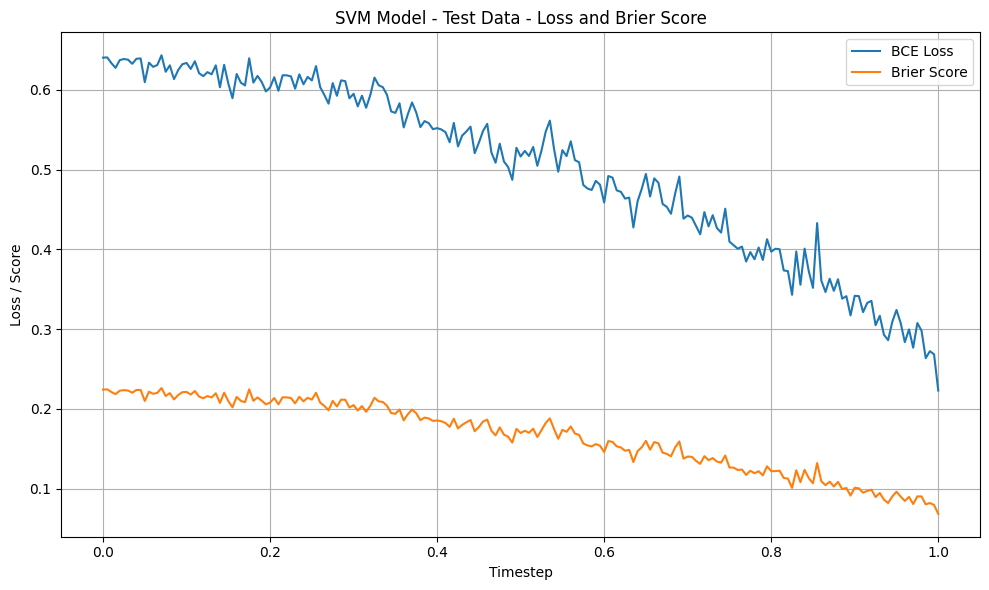

In [12]:
# Plot accuracy and loss on validation data
plot(models, test_data, title="SVM Model - Validation Data")

# Plot accuracy and loss on test data
plot(models, test_data, title="SVM Model - Test Data")


In [ ]:
# Save the models
import pickle
filename = 'svm_model.pickle'
pickle.dump(models, open(filename, 'wb'))
print(f"Models saved to {filename}")


In [ ]:
write_predictions(models, interpolated_dir, test_years, history_length, features, replace_nan_val=0, phat_b="phat_b_SVM")

Loading data for 2025
Processed file:  game_401772888.csv
Processed file:  game_401772863.csv
Processed file:  game_401772877.csv
Processed file:  game_401772730.csv
Processed file:  game_401772724.csv
Processed file:  game_401772718.csv
Processed file:  game_401772917.csv
Processed file:  game_401772903.csv
Processed file:  game_401772902.csv
Processed file:  game_401772916.csv
Processed file:  game_401772719.csv
Processed file:  game_401772725.csv
Processed file:  game_401772731.csv
Processed file:  game_401772876.csv
Processed file:  game_401772862.csv
Processed file:  game_401772889.csv
Processed file:  game_401772848.csv
Processed file:  game_401772874.csv
Processed file:  game_401772860.csv
Processed file:  game_401772727.csv
Processed file:  game_401772733.csv
Processed file:  game_401772928.csv
Processed file:  game_401772900.csv
Processed file:  game_401772914.csv
Processed file:  game_401772915.csv
Processed file:  game_401772901.csv
Processed file:  game_401772929.csv
Proces

In [14]:
import os
import shutil

# Define the ancestor directory and the parent directory
src_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
dest_dir = os.path.abspath(os.path.join(os.getcwd(), "../../"))

# Specify a list of directories to copy
sources = [
    os.path.join(src_dir, "dataset_interpolated_fixed", "2024"),
    os.path.join(src_dir, "dataset_interpolated_fixed", "2025")
]

destination = os.path.join(dest_dir, "test_final", "svm_model")

# Iterate through each source and copy
for source in sources:
    if os.path.exists(source):
        # Extract the year/folder name from source
        if os.path.isdir(source):
            shutil.copytree(source, destination, dirs_exist_ok=True)
        else:
            shutil.copy2(source, destination)
        print(f"Copied '{source}' to '{destination}'")
    else:
        print(f"Source '{source}' does not exist")

Copied '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML/dataset_interpolated_fixed/2024' to '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/test_final/svm_model'
Copied '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML/dataset_interpolated_fixed/2025' to '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/test_final/svm_model'
